## 11. Rolling Correlations / Relationship Stability

This section checks whether CPI-predictor relationships are stable through time. It reuses the stationary transformations from the CCF section and applies forecast-safe lags where engineered lag features are available. These diagnostics are supplementary and are not fed back into the Section 10 include/exclude logic.

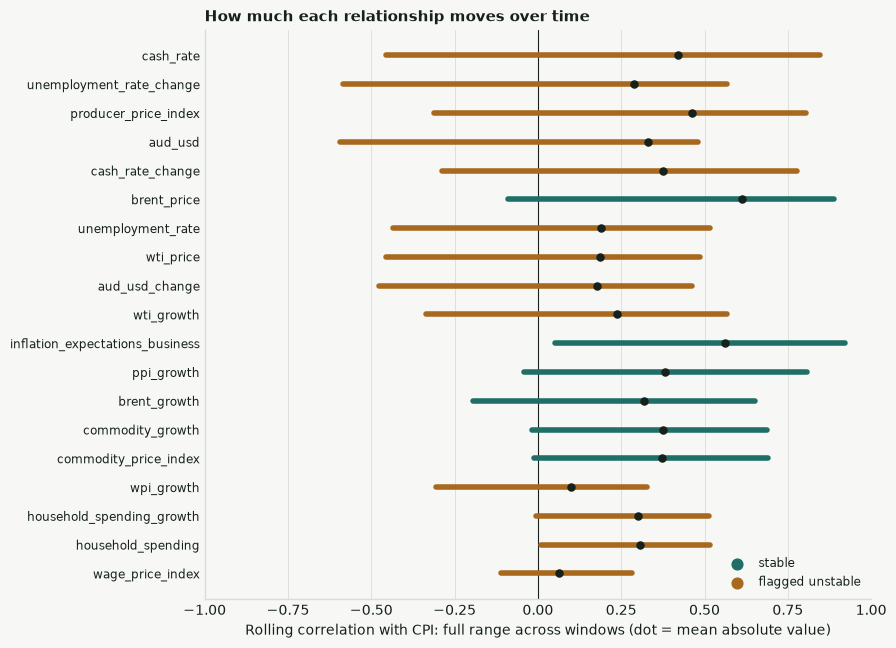

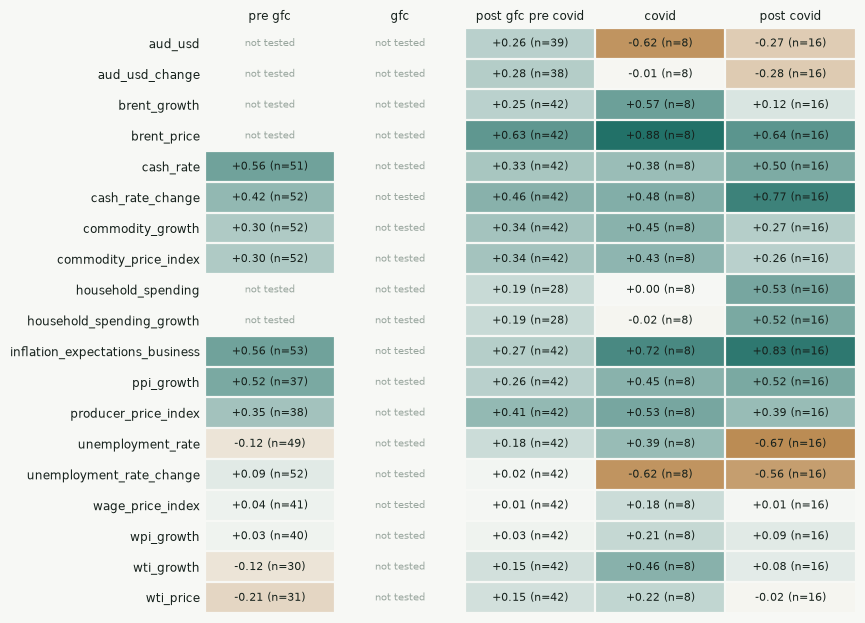

Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.

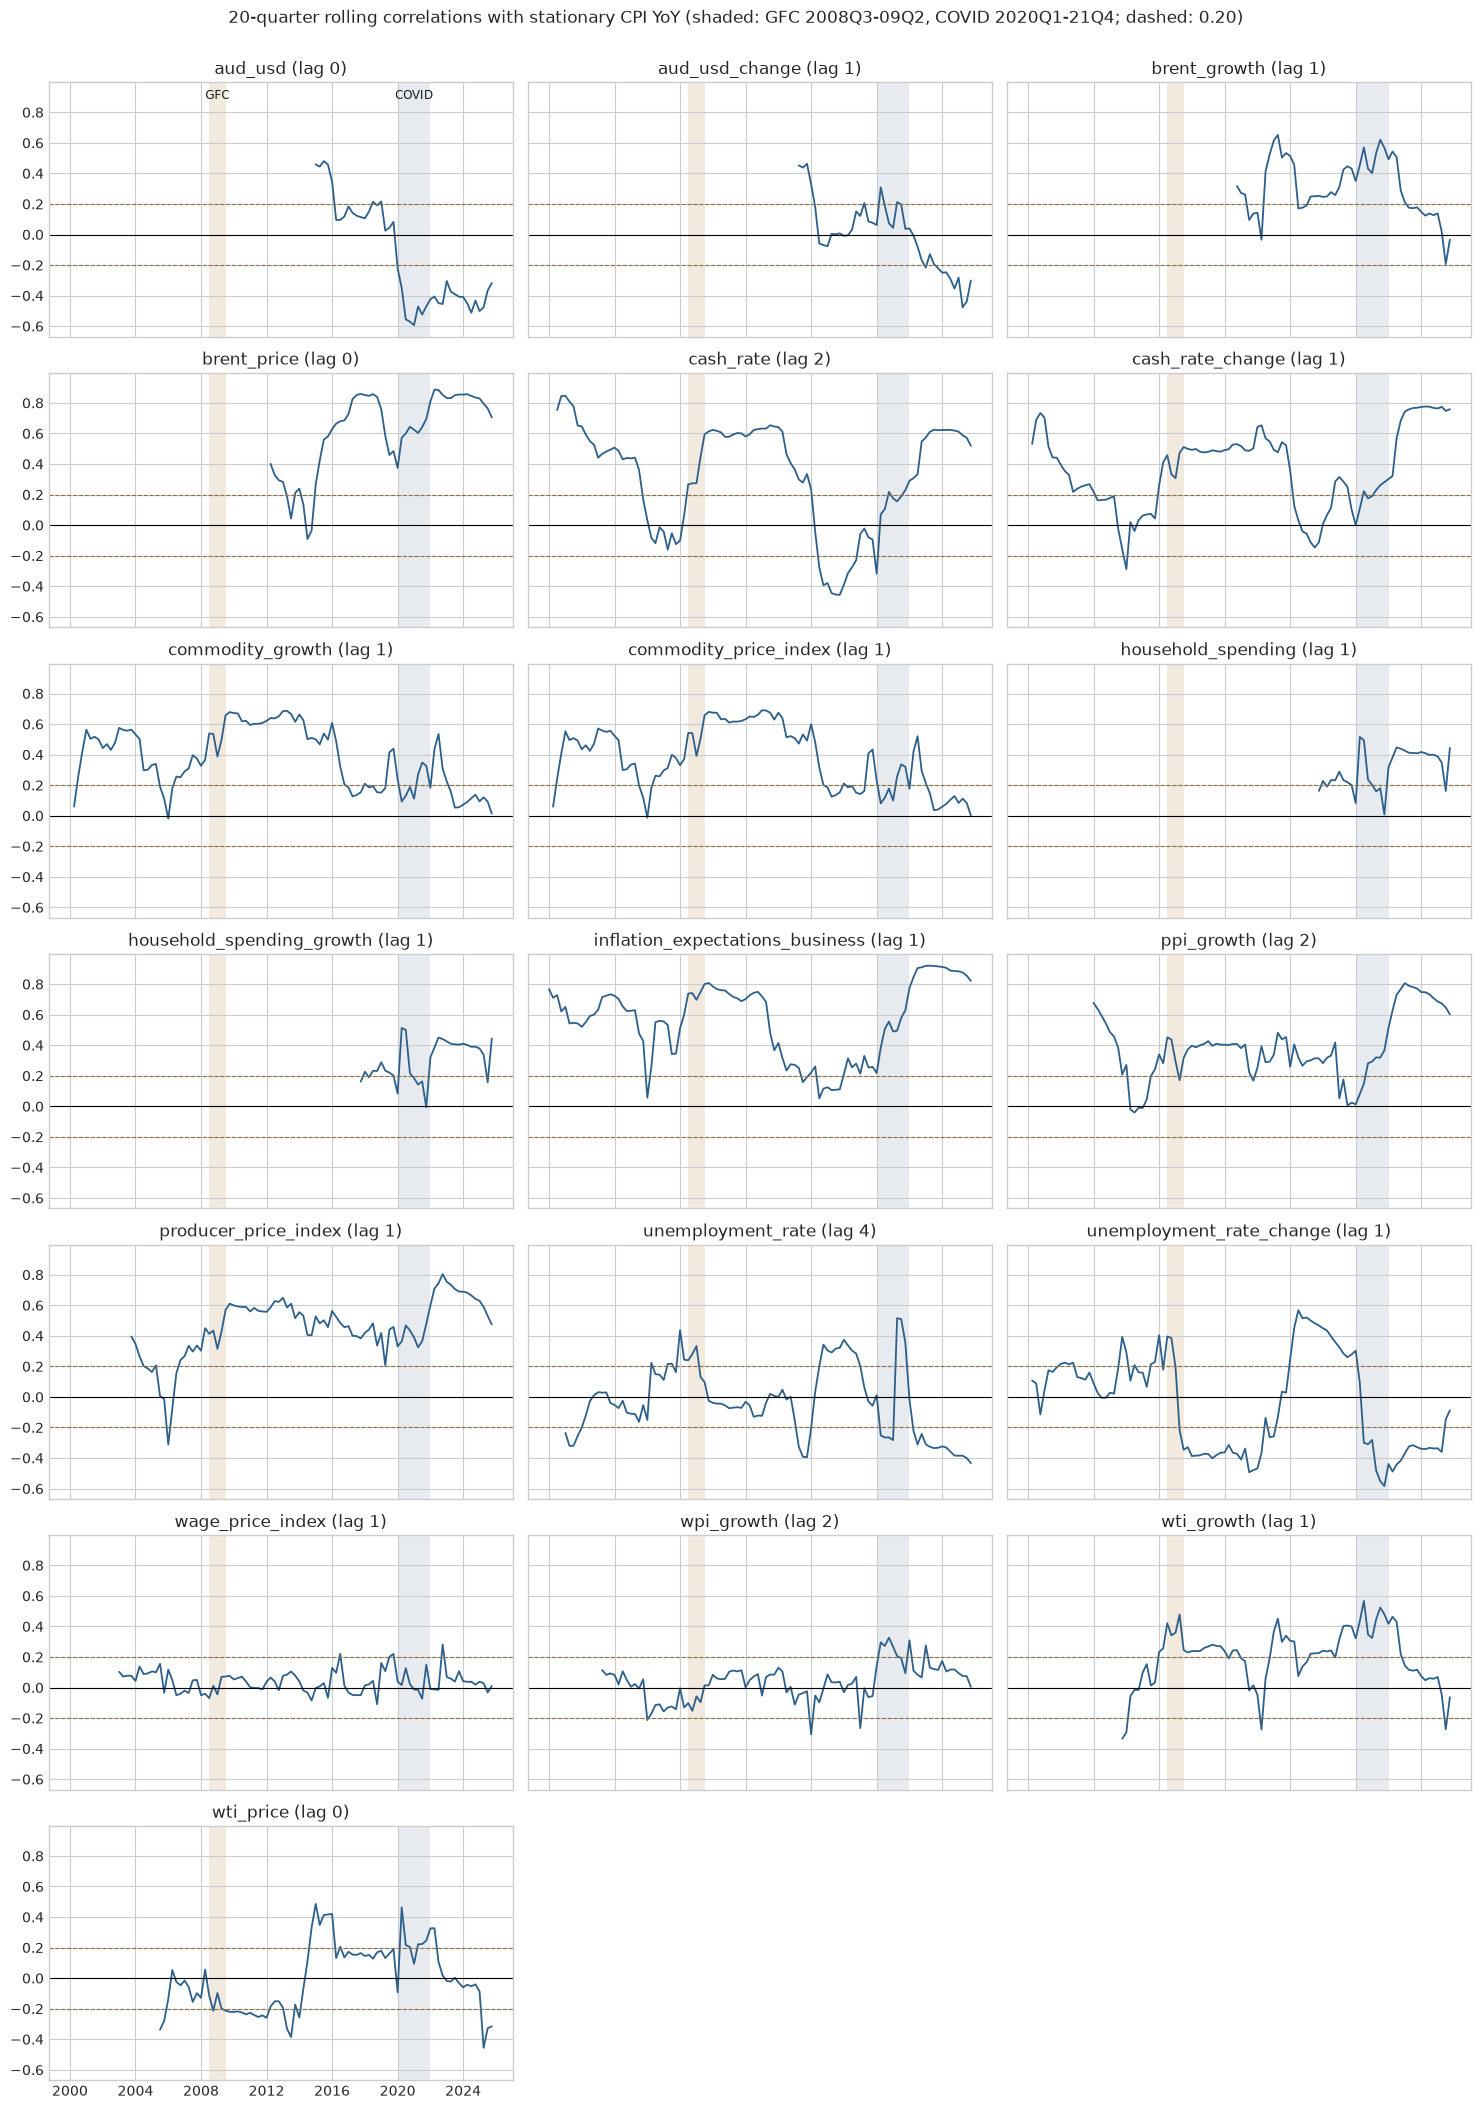

In [14]:
ROLLING_WINDOW = 20

def rolling_feature_lag(variable: str) -> int:
    chosen_feature = chosen_feature_by_base.get(variable)
    if chosen_feature is not None and pd.notna(feature_lag(chosen_feature)):
        return int(feature_lag(chosen_feature))
    return min_safe_lag_for_base(variable) if variable in availability_lookup else 0


def count_strong_sign_changes(corr: pd.Series, threshold: float) -> int:
    strong = corr.dropna()[corr.dropna().abs() >= threshold]
    signs = np.sign(strong)
    if len(signs) <= 1:
        return 0
    return int((signs != signs.shift()).sum() - 1)

rolling_corr_frames = []
period_rows = []
for variable in EXTERNAL_BASE_COLS:
    lag = rolling_feature_lag(variable)
    x_stationary = stationary_series(variable).rename(variable).shift(lag)
    aligned = pd.concat([target_stationary.rename(TARGET), x_stationary], axis=1).dropna()
    if len(aligned) < ROLLING_WINDOW:
        continue
    rolling_corr = aligned[TARGET].rolling(ROLLING_WINDOW).corr(aligned[variable]).dropna()
    rolling_corr_frames.append(pd.DataFrame({'quarter_period': rolling_corr.index, 'variable': variable, 'rolling_corr': rolling_corr.values, 'lag_used': lag}))

    periods = {
        'pre_gfc': aligned.index < pd.Period('2008Q3', freq='Q'),
        'gfc': (aligned.index >= pd.Period('2008Q3', freq='Q')) & (aligned.index <= pd.Period('2009Q2', freq='Q')),
        'post_gfc_pre_covid': (aligned.index >= pd.Period('2009Q3', freq='Q')) & (aligned.index < pd.Period('2020Q1', freq='Q')),
        'covid': (aligned.index >= pd.Period('2020Q1', freq='Q')) & (aligned.index <= pd.Period('2021Q4', freq='Q')),
        'post_covid': aligned.index >= pd.Period('2022Q1', freq='Q'),
    }
    for period_name, mask in periods.items():
        subset = aligned.loc[mask]
        period_rows.append({
            'variable': variable,
            'period': period_name,
            'lag_used': lag,
            'n_obs': int(len(subset)),
            'period_corr': subset[TARGET].corr(subset[variable]) if len(subset) >= 8 else np.nan,
        })

rolling_corrs = pd.concat(rolling_corr_frames, ignore_index=True) if rolling_corr_frames else pd.DataFrame(columns=['quarter_period', 'variable', 'rolling_corr', 'lag_used'])
period_correlation = pd.DataFrame(period_rows)

stability_rows = []
for variable, group in rolling_corrs.groupby('variable'):
    corr = group['rolling_corr'].dropna()
    signs = np.sign(corr.replace(0, np.nan)).dropna()
    raw_sign_changes = int((signs != signs.shift()).sum() - 1) if len(signs) > 1 else 0
    strong_sign_changes = count_strong_sign_changes(corr, SIGNAL_CORR_THRESHOLD)
    weak_share = float((corr.abs() < SIGNAL_CORR_THRESHOLD).mean()) if len(corr) else np.nan
    period_values = period_correlation.loc[period_correlation['variable'] == variable].set_index('period')['period_corr']
    pre_covid_abs_values = period_values.reindex(['pre_gfc', 'gfc', 'post_gfc_pre_covid']).abs().dropna()
    pre_abs = pre_covid_abs_values.max() if not pre_covid_abs_values.empty else np.nan
    covid_abs = abs(period_values.get('covid', np.nan))
    post_abs = abs(period_values.get('post_covid', np.nan))
    crisis_or_post_signal = (pd.notna(covid_abs) and covid_abs >= SIGNAL_CORR_THRESHOLD) or (pd.notna(post_abs) and post_abs >= SIGNAL_CORR_THRESHOLD)
    covid_or_post_only = bool(crisis_or_post_signal and (pd.isna(pre_abs) or pre_abs < SIGNAL_CORR_THRESHOLD))
    stability_rows.append({
        'variable': variable,
        'lag_used': int(group['lag_used'].iloc[0]),
        'rolling_windows': int(len(corr)),
        'rolling_corr_min': corr.min(),
        'rolling_corr_max': corr.max(),
        'mean_abs_rolling_corr': corr.abs().mean(),
        'rolling_corr_std': corr.std(),
        'raw_sign_changes': max(raw_sign_changes, 0),
        'strong_sign_changes': max(strong_sign_changes, 0),
        'weak_window_share': weak_share,
        'covid_or_post_covid_only_signal': covid_or_post_only,
        'sign_change': bool(max(strong_sign_changes, 0) > 0),
        'rolling_relationship_stable': not bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
        'stability_warning': '; '.join([reason for condition, reason in [
            (max(strong_sign_changes, 0) > 0, 'strong sign change'),
            (weak_share > 0.50, 'weak in more than half of rolling windows'),
            (corr.std() > 0.30, 'large rolling-correlation variation'),
            (covid_or_post_only, 'signal concentrated in COVID/post-COVID period'),
        ] if condition]),
        'unstable_flag': bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
    })

stability_summary = pd.DataFrame(stability_rows).sort_values(['unstable_flag', 'weak_window_share', 'rolling_corr_std'], ascending=[False, False, False])
with plt.rc_context(BOOK_STYLE):
    s = stability_summary.copy()
    s["span"] = s["rolling_corr_max"] - s["rolling_corr_min"]
    s = s.sort_values("span").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(8.6, 0.3 * len(s) + 1.7))
    ax.axvline(0, color=INK, linewidth=0.8)
    for y, r in s.iterrows():
        stable = bool(r["rolling_relationship_stable"])
        ax.plot([r["rolling_corr_min"], r["rolling_corr_max"]], [y, y], color=ACCENT if stable else HIGHLIGHT, linewidth=4,
                solid_capstyle="round", zorder=2)
        ax.scatter([r["mean_abs_rolling_corr"]], [y], s=26, color=INK, zorder=3)
    ax.set_yticks(s.index, s["variable"], fontsize=8.4)
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Rolling correlation with CPI: full range across windows (dot = mean absolute value)")
    ax.set_title("How much each relationship moves over time", loc="left", fontsize=11, fontweight="bold")
    ax.scatter([], [], s=60, color=ACCENT, label="stable")
    ax.scatter([], [], s=60, color=HIGHLIGHT, label="flagged unstable")
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    ax.grid(axis="y", visible=False)
    plt.show()

period_display = period_correlation.copy()
period_display['corr_with_n'] = period_display.apply(
    lambda row: 'not tested' if pd.isna(row['period_corr']) else f"{row['period_corr']:.2f} (n={int(row['n_obs'])})",
    axis=1,
)
with plt.rc_context(BOOK_STYLE):
    from matplotlib.colors import LinearSegmentedColormap
    wide = period_display.pivot(index="variable", columns="period", values="corr_with_n")
    order = ["pre_gfc", "gfc", "post_gfc_pre_covid", "covid", "post_covid"]
    wide = wide[[c for c in order if c in wide.columns]]
    pat = r"(-?[0-9.]+) [(]n=([0-9]+)[)]"
    corr = wide.apply(lambda col: col.astype(str).str.extract(pat)[0].astype(float))
    n = wide.apply(lambda col: col.astype(str).str.extract(pat)[1])
    cmap = LinearSegmentedColormap.from_list("amber_teal", [HIGHLIGHT, PAPER, ACCENT])
    fig, ax = plt.subplots(figsize=(8.4, 0.3 * len(corr) + 1.9))
    ax.imshow(np.ma.masked_invalid(corr.to_numpy()), cmap=cmap, vmin=-0.9, vmax=0.9, aspect="auto")
    for (i, j), val in np.ndenumerate(corr.to_numpy()):
        if np.isnan(val):
            ax.text(j, i, "not tested", ha="center", va="center", fontsize=7.2, color=MUTED)
        else:
            ax.text(j, i, f"{val:+.2f} (n={n.iloc[i, j]})", ha="center", va="center", fontsize=7.6)
    ax.set_xticks(range(corr.shape[1]), [c.replace("_", " ") for c in corr.columns], fontsize=8.6)
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(corr)), corr.index, fontsize=8.4)
    ax.set_xticks(np.arange(-0.5, corr.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, len(corr)), minor=True)
    ax.grid(which="minor", color=PAPER, linewidth=1.6)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="both", length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    plt.show()
display(Markdown('Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.'))

shortlist_with_stability = shortlist.merge(
    stability_summary[['variable', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']],
    on='variable',
    how='left',
)

def shade_events(ax, label=False, where="top", windows=None, alpha=0.14):
    """GFC and COVID as light full-height bands: one definition of the periods and colours for the whole book.
    label=True also names each band in plain text (do that once per figure); `where` is "top" or "bottom"
    (or a {name: position} dict); `windows` overrides {name: (first quarter, last quarter, colour)}."""
    periods = {"GFC": ("2008Q3", "2009Q3", "#a8691f"), "COVID": ("2020Q1", "2022Q1", "#5b6f8f")}
    periods.update(windows or {})
    for name, (start, end, colour) in periods.items():
        s, e = pd.Period(start, "Q").to_timestamp(), pd.Period(end, "Q").to_timestamp()
        ax.axvspan(s, e, color=colour, alpha=alpha, linewidth=0, zorder=0)
        if label:
            pos = where.get(name, "top") if isinstance(where, dict) else where
            ax.text(s + (e - s) / 2, 0.97 if pos == "top" else 0.03, name, transform=ax.get_xaxis_transform(), ha="center",
                    va="top" if pos == "top" else "bottom", fontsize=8.5, color="#16211c", zorder=1)

if not rolling_corrs.empty:
    n_cols = 3
    n_rows = int(np.ceil(rolling_corrs['variable'].nunique() / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.0 * n_rows)), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, (variable, group) in zip(axes, rolling_corrs.groupby('variable')):
        plot_dates = pd.PeriodIndex(group['quarter_period'], freq='Q').to_timestamp(how='start')
        ax.plot(plot_dates, group['rolling_corr'], color='#2c5f8a', linewidth=1.3)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axhline(-SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        shade_events(ax, label=(ax is axes[0]), where="top")
        ax.set_title(f'{variable} (lag {int(group["lag_used"].iloc[0])})')
    for ax in axes[rolling_corrs['variable'].nunique():]:
        ax.axis('off')
    fig.suptitle(f'{ROLLING_WINDOW}-quarter rolling correlations with stationary CPI YoY (shaded: GFC 2008Q3-09Q2, COVID 2020Q1-21Q4; dashed: 0.20)', y=1.002)
    fig.tight_layout()
    plt.show()

**Interpretation.** Several of the strongest full-sample correlates turn out to be
unstable once the sample is split into sub-periods. `inflation_expectations_business`
swings from 0.27 (post-GFC, pre-COVID) to 0.83 (post-COVID), a relationship that looks very
different depending on which decade you're in. `aud_usd` is more extreme: its correlation
with CPI actually *flips sign* between windows (-0.62 during COVID vs. +0.26 post-GFC),
though on a small sample (n=8 in the COVID window). This directly qualifies the [SVAR
ordering assumption](../04_modeling/44_svar) discussed in §4.4: a single fixed causal
ordering, estimated once over the full sample, is implicitly averaging over relationships
that weren't actually stable the whole time.